# Source Power Comodulation

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Get familiar with the MNE toolbox for analysis and regression of neural oscillations using SPoC;
- Understand source power comodulation (SPoC);
- Understand the differences between CSP and SPoC.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.

**Note:**
In providing your answers to the questions, please denote which question you are providing an answer to (either in text or code) by commenting it with something like "Exercise 1.1" and "Exercise 3.4". This improves readability of your solutions as well as the quality of the feedback you will get.


## Top-down view onto this notebook

In this notebook you will perform an EEG analysis using source power comodulation (SPoC), i.e., determining an oscillatory linear subspace that is informative about a *continuous* class label. For this, we work with a dataset that we have seen before in assignment 09 (CSP). This means that the initial exercises will be a repetition of what you have seen before.

Before going into the current assignment, it is recommended to:
- familiarize yourself with SPoC by reading [Dähne et al.](https://www.sciencedirect.com/science/article/pii/S1053811913008483);
- familiarize yourself with MNE's SPoC implementation by going through its EMG decoding from MEG tutorial, see [this link](https://mne.tools/stable/auto_examples/decoding/decoding_spoc_CMC.html);
- familiarize yourself with the DBS dataset that we use here, by reading the published study by [Castaño-Candamil et al.](https://www.sciencedirect.com/science/article/pii/S2213158220302138).

Labels available in this data indicate whether the DBS stimulation had been *turned on* or *turned off* during a trial of a hand motor task (binary labels for classification with e.g. CSP and LDA). Additionally, there are features that provide information on the hand motor task (e.g., speed, velocity, acceleration) that has been executed by the patient (continuous labels for regression with e.g. SPoC and linear regression). The latter will be used in the context of this assignment. 

In the CSP assignment (assignment 09), this was enough to start decoding of the catergorical variable `label`. This classification would allow us to find brain sources (CSP components) that are descriptive of the DBS stimulation. In return, we might turn on or off DBS stimulation depending on the brain activity in a closed-loop system. 

In this assignment, we will perform regression instead of classification. Specifically, we define a continuous variable that describes the performance of hand movement. In fact, what we are interested in is which brain sources comodulate with this behavioural response, so that we can, from brain activity instead of behavioural data, derive the quality of the hand movement, and if necessary modify the DBS stimulation in order to improve hand performance in a closed-loop system. However, since we do not have direct access to these brain sources, we first need to indentify it, for which we will use SPoC, which finds those brain components that comodulate with a certain continuous variable, for which we choose hand performance.

This assignment will guide you through the following:
1. In exercise 1, you will revisit the core theoretical concepts of SPoC and compare it with CSP which you have discussed in lecture and assignment 9;
2. In exercise 2, you will first download the data and setup it up so that you can work with it in this notebook;
3. In exercise 3, you will apply an ICA (which includes a PCA) to remove several artefactual components (like in assignment 09);
4. In exercise 4, you define a continuous variable that describes the performance of hand movement. Since we have multiple behavioural hand features, you will perform LDA to find a linear combination of these features (the continuous motor performance label);
5. In exercise 5, you will search for the brain sources that comodulate with this motor performance label by applying SPoC. Instead of using one SPoC component, you will use Ridge regression (regression with shrinkage) to find a linear combination of several SPoC components to regress the motor performance label;
6. In exercise 6, you will inspect the spatial patterns obtained by SPoC;
7. In exercise 7, you will inspect the SPoC components. 

In [1]:
import os
import pickle
import mne
from mne.decoding import SPoC
from scipy.stats import pearsonr
from scipy.signal import periodogram, hilbert
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import roc_auc_score, make_scorer
import seaborn as sns
import numpy as np
import yaml

mne.set_log_level('WARNING')

np.random.seed(42)

## Exercise 1: Core theoretical concepts of SPoC
The lecture and the three sources above should have provided you with a good overview of the SPoC algorithm and its underlying mathematical optimization problem. Try to answer the following questions to rehearse your understanding of the basic concepts.

**Questions**:
1. Please write down the optimization equation and describe all variables, including a description of their dimensions.
2. In your own words, please describe the goal of the above optimization problem.
3. Please describe the difference between the SPoC and CSP optimization porblem in your own words.
4. Would SPoC and CSP yield the same result, if the regression target could only take values in {-1, 1}?

1. 
Optimization problem for $SPoC_{r^2}$:

$ \displaystyle \arg \max_{w} \ \frac{\mathrm{Cov}\left(w^{T}(C(e)-\bar{C})w,\ z(e)\right)^2}{Var(w^{T}(C(e) -\bar{C})w)Var(z(e))} = \frac{(w^{T} C_z w)^2}{\langle (w^{T}( C(e) - \bar{C}) w)^2 \rangle} $



Optimization problem for $SPoC_{λ}$:

$ \displaystyle \arg\max_{w} \ \frac{\mathrm{Cov}\left(w^{T}(C(e)-\bar{C})w,\ z(e)\right)}{w^{T}\bar{C}w} = \frac{w^{T}\langle C(e),z(e)\rangle w}{w^{T}\bar{C}w} $

$C_z = \frac{1}{N} \sum_{i=1}^N z_i C_i
$

and the average covariance:

$
\bar{C} = \frac{1}{N} \sum_{i=1}^N C_i.
$

SPoC solves:

$
\max_{w} \; w^\top C_z w
\quad \text{subject to} \quad
w^\top \bar{C} w = 1.
$

This yields the generalized eigenvalue problem:

$
C_z w = \lambda \bar{C} w.
$

Description: e denote epochs, z(e) are the continuous, epoch-wise, scalar labels, C(e) the epoch-wise covariance matrices, and C denotes the average covariance matrix over epochs. Moreover <...> means averaged over all epochs e and C_z it is the abbreviations of $ \langle C(e),z(e) \rangle$

Dimensions:
$X \in \mathbb{R}^{C \times T}$, $w \in \mathbb{R}^{C \times 1}$, $C \in \mathbb{R}^{C \times C}$, $z_i \in \mathbb{R}$.

2. The goal of the optimization problem is to find a spatial filter $\mathbf{w}$ that maximizes how much the target variable z comudalates the spatially filter SPoC signal.

3. CSP (Common Spatial Patterns):
* works with 2 discrete classes
* maximizes the contrast between the signals of class-specific covariances $C_1$ and $C_2$

SPoC:
* works with a continuous label $z$
* maximizes variance between source power and the continous label z

So they key difference is that one deals with classification and other regression.

4. No, SPoC and CSP do not become equivalent even if $z$ takes only values $-1$ and $+1$ becase:

SPoC uses the weighted covariance $ C_z$ 
and optimises $ w^\top C_z w $.

CSP uses class-specific covariances $C_1$ and $C_2$ and optimises a variance ratio.

These are different matrices and different optimisation objectives.
They only match under very special, non-generic conditions.

## Exercise 2: Download, setup, and load the raw data

The datasets used here are from Castaño-Candamil et al. and have been obtained in the context of a patient study on deep brain stimulation (DBS). Please do not publish or distribute this data, it is only for teaching purposes! 

The code snippet below will load the data of one particular participant, set with the variable `i_subject`.

1. Retrieve the data from BrightSpace and store it at a convenient location locally (the data are those from assignment 09, i.e., the dbs_subject_#);
1. In the code snippet below, set the `CONFIG_FILE_PATH` to point the folder where the `config.yaml` file is located;
1. Open the `config.yaml` file in a text editor, and change the `data_path` to point to the path where you downloaded the data.

**Questions**:
Please inspect the following:
1. What is the dimensionality of the data: how many (EEG) channels do we have? I.e., look into `raw`.
2. What is the sampling frequency? I.e., look into `raw.info`. Derive the duration of this session by combining the dimensionality of the data and the sampling frequency.
3. Did we already apply preprocessing to the data? I.e., look into `raw.info` (**Hint:** there are at least 3 fields that may hint you there has been minimal preprocessing steps applied already).


In [2]:
# Adjust this CONFIG_FILE_PATH to point to the config.yaml file
CONFIG_FILE_PATH = os.path.join(os.getcwd(), 'data', 'config.yaml')

# Load the file
with open(CONFIG_FILE_PATH, 'r') as fid:
    config = yaml.safe_load(fid)   
    
# Change to load another subject
i_subject = 0  

# load data
fn = os.path.join(config['data_path'], config['dbs_csp']['session_list'][i_subject], 'copyDraw-raw.fif')
raw = mne.io.read_raw_fif(fn, preload=True)

# Broad spectral filter
raw.filter(1, 40)

print("Number of channels:", len(raw.ch_names))
print("Sample frequency:", raw.info["sfreq"], "Hz")
print(raw.info)

Number of channels: 70
Sample frequency: 200.0 Hz
<Info | 10 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 63 EEG, 1 EOG, 6 misc
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 file_id: 4 items (dict)
 highpass: 1.0 Hz
 lowpass: 40.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 70
 projs: []
 sfreq: 200.0 Hz
>


In [3]:
# Answer here
data = raw.get_data()
duration = data.shape[1]/ (raw.info["sfreq"])
print("The dimensionality of the data is", data.shape)
print(f"Duration is {duration} seconds or {duration/60} minutes")


The dimensionality of the data is (70, 822816)
Duration is 4114.08 seconds or 68.568 minutes


70 channels 63 EEG, 1 EOG and 6 miscellenaeous.
Sampling frequency is 200.0 Hz
Yes, there is minimal preprocessing already applied. This is visible in raw.info:  
highpass: 1.0 Hz, lowpass: 40.0 Hz  
bads: [] → bad channel detection step is completed and there are no bad channels


## Exercise 3: ICA and epoching

ICA analysis and identification of neural vs. artifactual components are out of scope for this assignment; we have discussed this in previous weeks. The distinction between artifactual / non-artifactual components is a whole topic by itself. It is recommended to check the following to learn about possible criteria used for rejecting or accepting a component:
- Read [Winkler et al.](https://link.springer.com/article/10.1186/1744-9081-7-30) on automatic classification of ICA componenets.
- See [this documentation](https://mne.tools/dev/generated/mne.preprocessing.ICA.html#mne.preprocessing.ICA) for how to use ICA in MNE. 

For the current dataset, ICA decomposition was already performed and artifactual components were already identified (manually). So we will first proceed to load the pre-trained ICA model.

In the preprocessing, prior to ICA analysis, noisy EEG channels were manually identified and marked for rejection based on their spectra and time series. For this reason, the ICA model loaded here may not contain all the channels originally contained in the raw timeseries model. Therefore, as a second step, we exclude specifically noisy EEG channels (they were determined in an earlier step) and non-EEG channels (like EOG and EMG channels) from our further analysis.

As a third step, we remove from the raw data the latent sources marked for exclusion in the pretrained ICA model. 

**Note**: many applications of SPoC decode a continuous variable over time by moving a sliding window (the epoch window) over continuous data. Here, we use epochs as well defined trials (like in the CSP assignment). 

**Questions**:
1. How many ICA components are removed by ICA? I.e., inspect the `ica` variable.
2. How many EEG channels are left in the data after projecting out the artefactual ICA components. I.e., inspect the `raw` variable after the `ica.apply(raw)` line. Can you explain you observation?
3. How many epochs do we have? What is their dimensionality and can you explain what they mean? I.e., inspect the `epo` variable.
5. Subsequently we read the DBS label information. What is the dimensionality of `labels`, what do the dimensions mean, and how is it related to the dimensionality of `epo`?
6. For a few epochs, plot both some EEG channels (`epo`) as well as some ICA components (epochs projected to ICA source space). Can you visually dissociate the EEG channels from the ICA components. Can you explain why this is (not) straightforward?

**Optional:**
This ICA analysis is not the focus of this notebook. For those interested, either using the raw or the segmented data (next exercise) you could inspect the ICA components using the `plot_properties()` method. It plots the spatial topography, time-series (of all epochs), power spectral density, and variance. With these, you could identify why certain sources were removed. 

In [ ]:
# Load the pre-defined ICA model
fn = os.path.join(config['data_path'], config['dbs_csp']['session_list'][i_subject], 'model-ica.fif')
ica = mne.preprocessing.read_ica(fn)

# Remove the noise and non-EEG channels from the raw data
ch_names = ica.ch_names
raw.pick_channels(ch_names)

print(raw)  # to inspect number of channel for ex.2
# Remove ica components from the raw data
raw = ica.apply(raw)
print(raw)

# Read events (i.e., markers)
events, events_id = mne.events_from_annotations(raw)
id_names = ['Stimulus/S {}'.format(i) for i in range(11, 17)]
sev = events[np.isin(events[:, 2], [events_id[n] for n in id_names])]

# Epoch data
epo = mne.Epochs(raw, sev, [events_id[id_name] for id_name in id_names], # loaded numbers 2-7 from event_id dict
                 tmin=-2, tmax=7.5, preload=True, 
                 reject=dict(eeg=100e-6), reject_tmin=-2)
epo.pick_types(eeg=True)

# Load the log file
fn = os.path.join(config['data_path'], config['dbs_csp']['session_list'][i_subject], 'session_log.p')
with open(fn, 'rb') as fid:
    df_sessionlog = pickle.load(fid)  # is a pandas dataframe

# Get which epochs were dropped due to artifacts - note the epo.drop_log is a list of tuples for all
# epochs as defined by the 'start_events', out of those quite a few where dropped due to the peak-to-peak amplitude
ix_good = [i for i, reason in enumerate(epo.drop_log) if reason == ()]
print('Number of epochs dropped due to artifacts (min-max): ', len(epo.drop_log) - len(ix_good))

# From the log, select only the trials that were not rejected during segmentation    
labels = np.array(df_sessionlog.loc[ix_good, 'stim'])
groups = np.array(df_sessionlog.loc[ix_good, 'ix_block'])

<Raw | copyDraw-raw.fif, 62 x 822816 (4114.1 s), ~389.3 MB, data loaded>
Number of epochs dropped due to artifacts (min-max):  86


In [ ]:
# print(events_id)
# print(sev)
print(ica)
print(f"There were {len(ica.exclude)} ICA components removed")
print(epo)
print(epo.get_data().shape)
print(labels.shape)

<ICA | epochs decomposition, method: fastica (fit in None iterations on 244617 samples), 61 ICA components (62 PCA components available), channel types: eeg, 33 sources marked for exclusion>
There were 33 ICA components removed
<Epochs | 129 events (all good), -2 – 7.5 s (baseline -2 – 0 s), ~116.1 MB, data loaded,
 '2': 24
 '3': 21
 '4': 22
 '5': 22
 '6': 20
 '7': 20>
(129, 62, 1901)
(129,)


# Question 2
After applying ICA the number of EEG channels is the same as before its application because ICA projects out component acitivity but does not delete channels

# Question 3
(epochs, EEG channels, n_times) 
Sample points in time window/n_times = (7.5 - (-2)) * 200 Hz = 9.5 * 200 = 1900+1 sample at the end

# Question 4
Labels variable has shape (129,), meaning one DBS label per epoch. The dimensionality matches the number of valid (non-dropped) epochs in epo.”

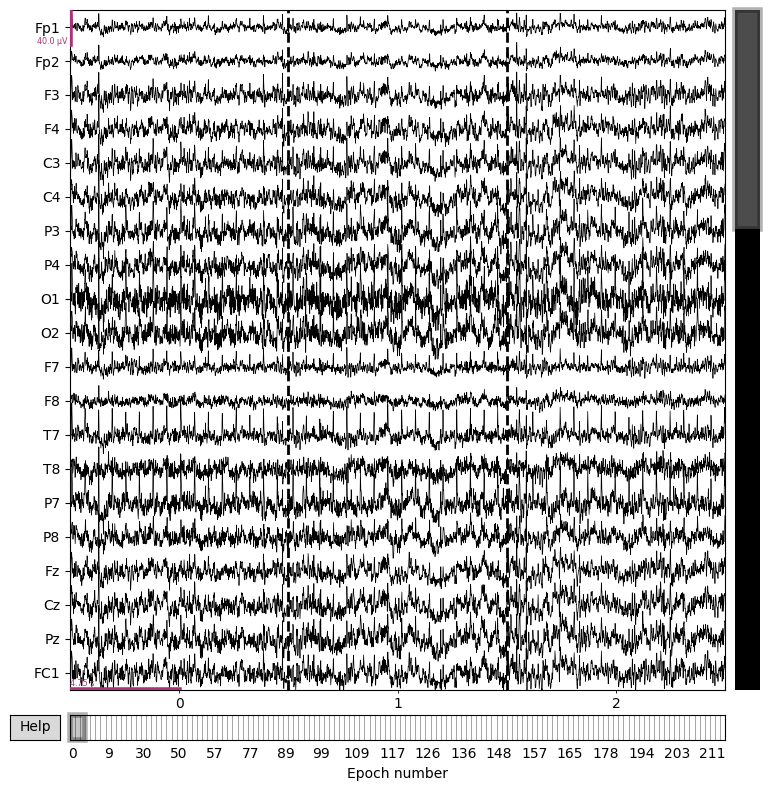

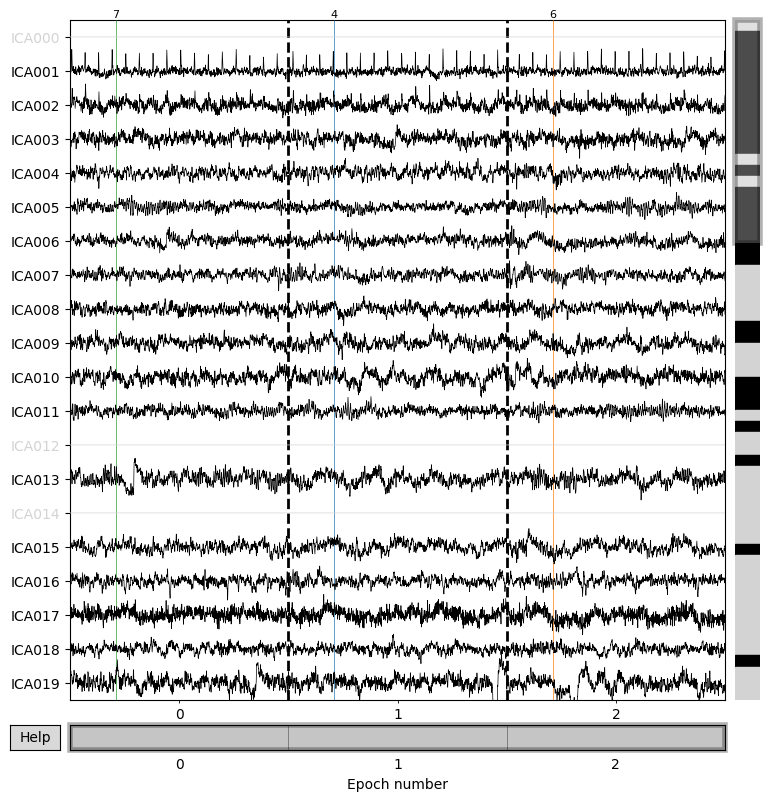

In [33]:
epo.plot(n_epochs=3, picks='eeg');
ica.plot_sources(epo[:3]);
# print()

# Question 5
Yes. The EEG channels show mixed activity from many brain and non-brain sources, making it difficult to distinguish specific patterns and there are similaraties between certain channels. In contrast, ICA components show much cleaner and more independent temporal patterns. This is because ICA separates the mixed EEG sensor signals into statistically independent latent sources, while EEG channels represent mixtures of these sources.

## Exercise 4: Decoding of continuous motor performance

The following part deals with a regression problem: we want to find an oscillatory component (a subspace defined by one or several spatial filters), such that the bandpower of this component co-modulates (i.e. correlates or co-varies) maximally with the hand motor performance obtained during the copyDraw task. In short, we would like to identify an oscillatory process, which can act as a substitute of the hand motor performance!

Before we tackle the actual regression problem, we face one more difficulty: 
How can we obtain a motor performance label? While we can obtain multiple performance features from the copyDraw task (e.g. speed of the pen, the jitter of the drawn trajectory etc.) we would like to obtain a single scalar label describing how well a hand motor trial overall has been executed by the patient. We of course expect, that the DBS condition (on vs. off) should influence this motor performance label. In short, we need to find a projection of some high-dimensional hand metric space down to a single, continuous performance dimension. 

Luckily, LDA can provide such a projection. For this, we extract multiple kinematic features from the execution of each copyDraw task, and train an LDA model with these features. As binary labels for LDA, we can use the DBS stimulation condition (on vs. off). In short, LDA will deliver us a scalar performance subspace, in which the stimulus condition maximally separates the performance values. After we have calculated these continuous performance labels (one per trial), we will be ready to continue to the actual regression problem.

Below, the continuous hand performance labels are plotted on the y-axis. The x-axis shows the order of trials as recorded during the experimental session (note, several of them were removed, see the `ix_good` variable). You can observe, that the DBS condition discriminates the trials quite well (AUC of about 0.90) but not perfectly.

Inspect the following:
1. What is the dimensionality of `x_motor`, and how is it related to the dimensionality of `labels`?
2. What does it mean to get the LDA AUC score of about 0.9?
3. What is the dimensionality of `z_label`, and how is it related to that of `labels`? What do those two variables mean? Which one is used for regression, and which one for classification, and why?
4. **Optional:** What is the variable `ix_good` representing (**Hint:** see exercise 2)? What does this mean for the balance of the dataset?


Text(0, 0.5, 'scalar hand perf. label')

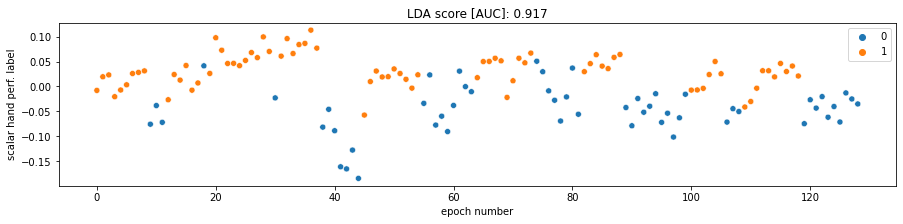

In [35]:
# select kinematic features from the sessionlog
motor_features = ['speed_sub','velocity_x_sub','velocity_y_sub',
                  'isj_sub','isj_x_sub','isj_y_sub','acceleration_sub',
                  'acceleration_x_sub','acceleration_y_sub']
df_motor = df_sessionlog[motor_features]
x_motor = df_motor.iloc[ix_good, :]

# Train LDA projection with DBS on/off labels
lda = LDA(solver='eigen', shrinkage='auto')
lda.fit(x_motor.values, labels)

# Project and normalize motor performance features, obtaining a final motor score
z_labels = lda.transform(StandardScaler().fit_transform(x_motor))
z_labels = np.squeeze(z_labels)

# Compute AUV
auc = roc_auc_score(df_sessionlog.loc[ix_good, 'stim'], z_labels)

# Plot
plt.figure(figsize=(15, 3))
sns.scatterplot(x=np.arange(labels.size), y=z_labels, hue=labels)
plt.title('LDA score [AUC]: {:.3f}'.format(auc))
plt.xlabel('epoch number')
plt.ylabel('scalar hand perf. label')


Answer here.

## Exercise 5: Train spatial components using SPoC

Using these continuous performance labels, we can apply source power comodulation (SPoC) to find oscillatory components that co-modulate with our target variable `z_labels`, i.e., the motor performance computed by the LDA projector above. For this, we will use the same EEG segments as we used for CSP in assignment 09.

SPoC comes in two important flavours: The first one optimizes the co-modulation using correlation. This formulation of the SPoC problem unfortunately does not allow for an analytical solution. Thus we will revert to the second flavour, which optimizes the covariance between the bandpower of extracted components and our performance labels instead of the correlation. This leads to a formulation of SPoCs optimization problem, which can be solved conveniently via a generalized eigenvalue problem. Please note, however, that solutions to an eigenvalue problem can have arbitrary scaling and sign!

If more than a single SPoC component is used to decode motor performance (four in our example), then an additional regression model (ridge regression in our example) needs to be employed, which learns how to linearly combine the multiple components to enhance the predictive power. Please note, that the performance of the regression model uses a different metric than in the binary classification examples from assignment 09!

1. Why do we need a regression step after SPoC? What is it doing?
2. We define a "custom" scoring function. Can you explain what the variables `z` and `z_pred` represent in the lambda function? I.e., what is it scoring?
3. SPoC defines components, though the MNE implementation `SPoC` performs an additional step. What specifically is the output of the e.g. the `.transform()` method, meaning, what is the input to the `Ridge()` regression? **Hint:** look into MNE's documentation of the SPoC class, and specifically look at the `transform_into` parameter and the `.transform()` method.
3. A classification performance, e.g. the classification accuracy, is quite easy to interpret. The performance of regression, e.g. a correlation, is a bit harder to interpret. Specifically, is the coefficient that you obtain a good one, or not? In previous weeks, we have discussed methods to obtain the significance of a particular test statistic by performing a *permutation test*. Implement a permutation test for the decoding pipeline below to inspect whether the observed regression is higher than chance. **Peek into solution:** the first participant is a very good participant. The correlation coefficient is 0.4, which is really high in the context of neuroimaging.

In [37]:
# Copy epochs
epo_training = epo.copy()

# Spectral filter
frequency_band = (10, 14)  # in Hertz
epo_training.filter(*frequency_band)

# Time interval
time_interval = (1, 6)  # in seconds
epo_training.crop(*time_interval)

# Extract data
epochs_data_train = epo_training.get_data()

# Note: a computational trick -> adding a minimal amount of noise for numeric stability.
# comment this out and try for yourself
epochs_data_train += np.random.randn(*epochs_data_train.shape) * 10**-12

# Build SPoC feature extractor
# N.B.: Instead of using all SPoC components, we limit it to deliver the four strongest only (sorted by eivenvalues)
n_components = 4
spoc = SPoC(n_components=n_components, reg=None, log=True)

# Linear regression, in case we use more than one SPoC component
ridge = Ridge()

# Set up the pipeline
regression_pipeline = Pipeline([('SPoC', spoc), ('regressor', ridge)])

# Set up the scoring function
pearson_scorer = make_scorer(lambda z, z_pred: pearsonr(z, z_pred)[0])

# Perform cross validation
cv = GroupKFold(n_splits=5)
scores = cross_val_score(regression_pipeline, epochs_data_train, z_labels, 
    cv=cv, groups=groups, n_jobs=1, scoring=pearson_scorer, verbose=0)

# Print the performance
print("Regression coefficient: {:f}".format(np.mean(scores)))


Regression coefficient: 0.451222


Answer here.

In [ ]:
# Answer here

## (Optional) Exercise 6: spatial patterns

Like we did for CSP in assignment 09, we can obtain SPoC spatial patterns for interpreting the spatial features used for the regression. Again, note that this step is prone to overfitting because we fit the SPoC on all data.

1. First a step back. Consider the general formulation $\mathbf{x}=\mathbf{w}^T\mathbf{X}$ in which data $\mathbf{X} \in \mathbb{R}^{c,m}$ of $c$ channels and $m$ samples and the spatial filter $\mathbf{w} \in \mathbb{R}^c$. In this context, what does it mean to *spatially filter* data? What are the individual elements in $\mathbf{w}$ conceptually? Is $\mathbf{x}$ in sensor space or in component space? What is the dimenionality of $\mathbf{x}$? 
2. Inspect the `cov` variable. What is it the covariance of?


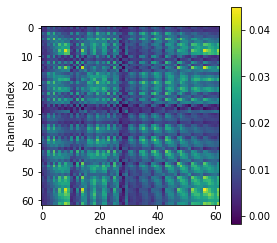

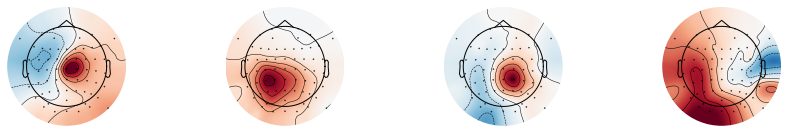

In [39]:
# Copy epochs -> if one was to just select subsets, filtering etc would overwrite the original data in epo
epo_training = epo.copy()

# Spectral filter
frequency_band = (10, 14)  # in Hertz
epo_training.filter(*frequency_band)

# Time interval
time_interval = (1, 6)  # in seconds
epo_training.crop(*time_interval)

# Data to numpy array
epochs_data_train = epo_training.get_data()

# Note: a computational trick -> adding a minimal amount of noise for numeric stability.
# comment this out and try for yourself
epochs_data_train += np.random.randn(*epochs_data_train.shape) * 10**-12

# Build SPoC features
n_components = 4
spoc = SPoC(n_components=n_components, reg=None, log=True)
spoc.fit(epochs_data_train, labels)

# Compute empirical covariance matrix in the target frequency band
data_concat =  np.hstack(epochs_data_train)    # stacked by time dimension
cov = np.dot(data_concat, data_concat.T)
cov = cov/np.linalg.norm(cov, 'fro')  # this scaling is not necessary, but color range of plots may be more adequate

# Visualize the covariance matrix
fig, ax = plt.subplots(1,1,figsize=(4, 4))
pos = ax.imshow(cov, interpolation='none')
fig.colorbar(pos, ax=ax)
ax.set_xlabel('channel index')
ax.set_ylabel('channel index')

# Visualize SPoC patterns
fig, ax = plt.subplots(1, n_components, figsize=(15, 2))
for i in range(n_components):
    mne.viz.plot_topomap(spoc.patterns_[i, :], epo.info, axes=ax[i], show=False)

Answer here.

## (Optional) Exercise 7: inspecting SPoC

With SPoC we find components that comodulate with a given continuous variable, here the motor performance. First, we want to inspect whether SPoC did a good job. Secondly, we would want to inspect the actual components by means of the temporal as well as spectral response properties.

1. Below we provide the code to visualize the comodulation of the projected band-power with the motor performance label. What is the dimensionality of the variable `data_spoc`? Can you give the conceptual meaning of the elements in this variable?
2. Inspect the resulting plots. Do the predictions covary with the performance label? How can you see this?
3. Can you oberve a pattern in the order of the components? Why are they ordered specifically this way? **Hint:** You may want to look up what SPoC is optimizing, and what we are showing here.
4. Plot the temporal and spectral response. For this you may want to refit the SPoC with the `transform_into` variable set to `csp_space` so that you retain the time dimension. For the temporal response, either plot indidual epochs, or compute the average absolute Hilbert transform. For the spectral response, compute the spectrogram and again, either plot individual epochs or the average. In this part, it may be useful to inspect different frequency-bands (e.g. a narrow band 10-14 Hz as well as a broad-band 2-40 Hz). Inspect the components' properties. What do you observe?

*In 4, it might happen SPoC starts fitting muscle artefacts that typically have a higher-frequency spectral response. This might also be visible in the spatial pattern.*

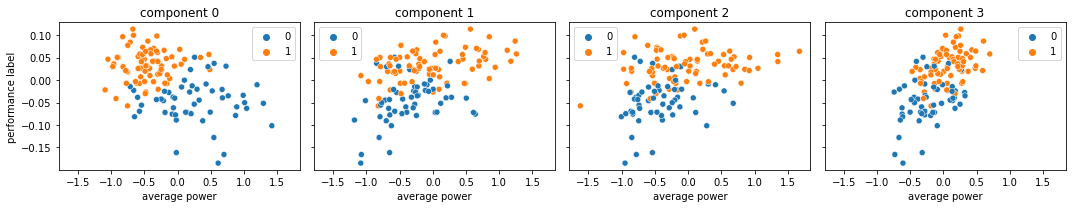

In [42]:
# Copy epochs
epo_training = epo.copy()

# Spectral filter
frequency_band = (10, 14)  # in Hertz
epo_training.filter(*frequency_band)

# Time interval
time_interval = (1, 6)  # in seconds
epo_training.crop(*time_interval)

# Extract data
data = epo_training.get_data()
data += np.random.randn(*data.shape) * 10**-12    # again the computational trick for stability

# Build SPoC features
n_components = 4
spoc = SPoC(n_components=n_components, reg=None, log=True)
spoc.fit(data, z_labels)

# Apply SPoC features
data_spoc = spoc.transform(data)

fig, ax = plt.subplots(1, n_components, figsize=(15, 3), sharex=True, sharey=True)
ax = ax.flatten()
for i in range(n_components):
    sns.scatterplot(x=data_spoc[:, i], y=z_labels, hue=labels, ax=ax[i])
    ax[i].set_xlabel("average power")
    ax[i].set_title("component " + str(i))
ax[0].set_ylabel("performance label")
fig.tight_layout()


Answer here

In [ ]:
# Answer here

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here